# PRC1.2: Class imbalance for Image Classification (TASK)

**Goals:**
This notebook is part of the first programming assignment (PRC1) for the course "Deep Learning for Visual Signal Processing I." In this notebook, you are required to undertake a series of tasks listed in the "2.TASKS" section. These tasks involve working with a custom dataset derived from the  [Places dataset](http://places.csail.mit.edu/browser.html) and utilize the `Pytorch` library for data processing

**Learning Objectives:**
* Engage with a hands-on tutorial on data augmentation using the `Python` functionality.
* Develop a practical understanding of various strategies for handling data imbalance and implement them effectively.
* Evaluate and clearly articulate the impact of these strategies on your model's performance.


**Expected Outcomes:**
* Notebooks: Generate separate notebooks for each experiment conducted during this task.
* Report: Submit a concise report (no more than two pages) that adheres to the specified course format, summarizing your findings and analyses.

**Estimated Completion Time:** The tasks are designed to be completed within an estimated timeframe of 3-5 hours when using GPU acceleration.

---

Author1: Sabbatini, Andrea (andrea.sabbatini@estudiante.uam.es)

Author2: Hamdy, Adham (adham.hamdy@estudiante.uam.es)

Author3: Ciurescu, Irina Alexandra (irinaa.ciurescu@estudiante.uam.es)

---
###### Course: Deep Learning for Visual Signal Processing I
###### Master in [Artificial Intelligence for Image Processing and Computer Vision (IPCVai)](https://ipcv.eu/)
######  [Escuela Politécnica Superior](https://www.uam.es/EPS/Home.htm), [Universidad Autónoma de Madrid](https://www.uam.es/)


# 1.Codebase for preparing your work

Please utilize the provided codebase in the notebooks you develop for this assignment. It contains essential scripts to access the dataset and establish the training partitions required for your tasks.

### 1-1.Install the required libraries

The submitted code must work with the following versions

Python 3.10 or above \
Pytorch 2.5.1+cu121 \
Torchvision 0.20.1+cu121 \
Albumentations 2.0.3


In [ ]:
!python --version

import torch
print(torch.__version__)

import torchvision
print(torchvision.__version__)

Python 3.12.12
2.9.0+cu126
0.24.0+cu126


###  1-2.Dataset loading
You will work with the [Scenes15](http://www-vpu.eps.uam.es/~jcs/DLVSP1/dataset_scenes15.zip) dataset, which features a diverse set of images intended for scene recognition tasks. Below are the key characteristics of this dataset:

* Classes: 15 (Kitchen, Store, Bedroom, LivingRoom, Office, Industrial, Suburb, InsideCity, TallBuilding, Street, Highway, OpenCountry, Coast, Mountain, Forest)
* Total: 4,485 color RGB images (albeit images do not contain color, being at gray level)
* Resolution: Images vary in resolution, adapting to different scene types and scales.

Use the following code to download the dataset:

In [ ]:
import os

# Download dataset
if os.path.isfile('dataset_scenes15.zip') == False:
  !wget http://www-vpu.eps.uam.es/~jcs/teaching/datasets/dataset_scenes15.zip

# Uncompress dataset
if os.path.isdir('/scenes15') == False:
  !unzip -o -q dataset_scenes15.zip -d .

# Class labels correspond to the subdirectories of the root folder
!ls ./scenes15/

Bedroom  Highway     Kitchen	 Office       Street
Coast	 Industrial  LivingRoom  OpenCountry  Suburb
Forest	 InsideCity  Mountain	 Store	      TallBuilding


### 1-3.Dataset partition (Train and Test)
As the dataset downloaded is not partitioned into train y test, we do it via the **random_split** function

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split

# Load the dataset from the directory
dataset_scene15_dir = './scenes15/'
dataset_scene15 = datasets.ImageFolder(root=dataset_scene15_dir, transform=None)

# create the partitions for train and test
train_test_ratio=0.8
total_size = len(dataset_scene15)
train_size = int(train_test_ratio * total_size)
test_size = total_size - train_size
dataset_scene15_train, dataset_scene15_test = random_split(dataset_scene15,
                                                          [train_size, test_size] ,
                                                           generator=torch.Generator().manual_seed(42))
print(f"Partition: Train {len(dataset_scene15_train)} samples, Test {len(dataset_scene15_test)} samples")

Partition: Train 3588 samples, Test 897 samples


### 1-4.Transformation definition
Utilize the `Pytorch` library, as explored in the tutorial, to define your data augmentation transformations. To manage computational resources effectively, we recommend incorporating a *Resize* transformation to standardize image dimensions to 128x128 for training.

Below is the baseline transformation setup. You are encouraged to add additional transformations based on your analysis and the needs of your project:

In [ ]:
from torchvision import transforms

# Define a basic transformation when loading the dataset
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize the image to 128x128 pixels
    transforms.ToTensor(),          # Convert images to tensor format
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize the images
])
print("ok")

ok


# 2.TASKS (graded with 7 points)
Dataset (common to all tasks): [Scenes15](http://www-vpu.eps.uam.es/~jcs/teaching/datasets/dataset_scenes15.zip)

You may reuse and adapt the PRC1.2 tutorial notebook.

**Task PRC1.2-AH-Q1: Transfer to a new dataset (3 points)**
* **Goal**: Show that you can transfer the class-imbalance pipeline from CIFAR-10 to a new dataset..

* **Task**:
1. Select any 6–10 classes from Scenes15, which are very different visually.
2. Create one imbalanced version of the dataset (your choice of imbalance).
3. Train:
- a baseline (no imbalance handling)
- one imbalance strategy (weighted loss or re-sampling)

* **Report**: Class distribution plot, Per-class accuracy (baseline vs strategy), Confusion matrix (test), Loss curves, Short answer to "Did the strategy improve minority classes compared to the baseline?"

**Task PRC1.2-AH-Q2: Strategy behavior under different imbalance structures (4 points)**
* **Goal**: Understand why imbalance strategies behave differently depending on the imbalance structure.

* **Task**:
Using the same model and dataset (Scenes15, all 15 classes):
1. Create two imbalance scenarios:
- Scenario A: uniform minority imbalance
- Scenario B: long-tailed imbalance (exponential decay)
2. Apply the same imbalance strategy to both scenarios (weighted loss or re-sampling — your choice).
3. Compare baseline vs strategies in both scenarios.

* **Report**: Two class-distribution plots (A vs B). Per-class accuracy tables (A vs B). Short discussion (10–12 lines total):
Why does the strategy behave differently in A vs B? Which classes benefit the most / least in each case? Why is long-tailed imbalance harder to fix than uniform imbalance?

**Additional Instructions**
* Notebooks Management: You are encouraged to create separate notebooks for each question to maintain organization. Clearly indicate in your report how each notebook corresponds to the specific questions.
* Coding: Feel free to use the code from the tutorial as a starting point for your assignments. Enhancements or modifications should be clearly marked and justified in your submissions.
* Citations: Ensure to cite any external sources or references used in your work. This includes documentation, research papers, or online resources that informed your decisions or provided code snippets.

In [ ]:
!pip install -q git+https://github.com/jcsma/dlvsp-utils.git

# utilities and functions for performance evaluation
from dlvsp_utils.metrics import (
    calculate_accuracy,
    compute_accuracy_stats,
    compute_accuracy_per_class,
    print_accuracy_report,
)

# utilities and functions for dataset handling
from dlvsp_utils.data import (
    apply_imbalance,
    exponential_decay_samples,
    define_imbalance_profile,
    count_samples_dataset,
    select_classes_dataset,
    inspect_dataset_classes,
)

# utilities and functions for visualization
from dlvsp_utils.viz import (
    plot_class_distribution,
    show_images,
)

print("✅ DLVSP utils imported: performance analysis and dataset handling ready!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ DLVSP utils imported: performance analysis and dataset handling ready!


In [ ]:
# Reload dataset WITH transforms (transform defined in section 1-4)
dataset_with_transform = datasets.ImageFolder(root=dataset_scene15_dir, transform=transform)

# Select 8 visually different classes FIRST (before splitting)
selected_class_names = dataset_with_transform.classes # using the q1 we are going to change it to all classes and apply the 2 scenarios

dataset_selected, class_names = select_classes_dataset(dataset_with_transform, selected_class_names)
num_classes = len(class_names)

# Now split the selected classes into train/test (same 80/20 ratio as section 1-3)
selected_train_size = int(0.8 * len(dataset_selected))
selected_test_size = len(dataset_selected) - selected_train_size

train_selected, test_selected = random_split(
    dataset_selected,
    [selected_train_size, selected_test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Selected {num_classes} classes: {class_names}")
print(f"Train samples: {len(train_selected)}, Test samples: {len(test_selected)}")
print("✅ Classes selected and split into train/test!")

Selected 15 classes: ['Bedroom', 'Coast', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']
Train samples: 3588, Test samples: 897
✅ Classes selected and split into train/test!


==========Scenario A==========
Imbalance config: type=uniform_minority, severity=medium
Desired samples: [32, 327, 32, 327, 327, 32, 327, 327, 327, 327, 327, 327, 327, 327, 327]
Minority classes: ['InsideCity', 'Bedroom', 'Forest']

TRAIN (imbalanced):
Classes present:
  Class 0 (Bedroom): 32 samples
  Class 1 (Coast): 286 samples
  Class 2 (Forest): 32 samples
  Class 3 (Highway): 212 samples
  Class 4 (Industrial): 247 samples
  Class 5 (InsideCity): 32 samples
  Class 6 (Kitchen): 174 samples
  Class 7 (LivingRoom): 224 samples
  Class 8 (Mountain): 302 samples
  Class 9 (Office): 173 samples
  Class 10 (OpenCountry): 327 samples
  Class 11 (Store): 250 samples
  Class 12 (Street): 236 samples
  Class 13 (Suburb): 191 samples
  Class 14 (TallBuilding): 291 samples

TEST (balanced):
Classes present:
  Class 0 (Bedroom): 51 samples
  Class 1 (Coast): 74 samples
  Class 2 (Forest): 73 samples
  Class 3 (Highway): 48 samples
  Class 4 (Industrial): 64 samples
  Class 5 (InsideCity): 53 

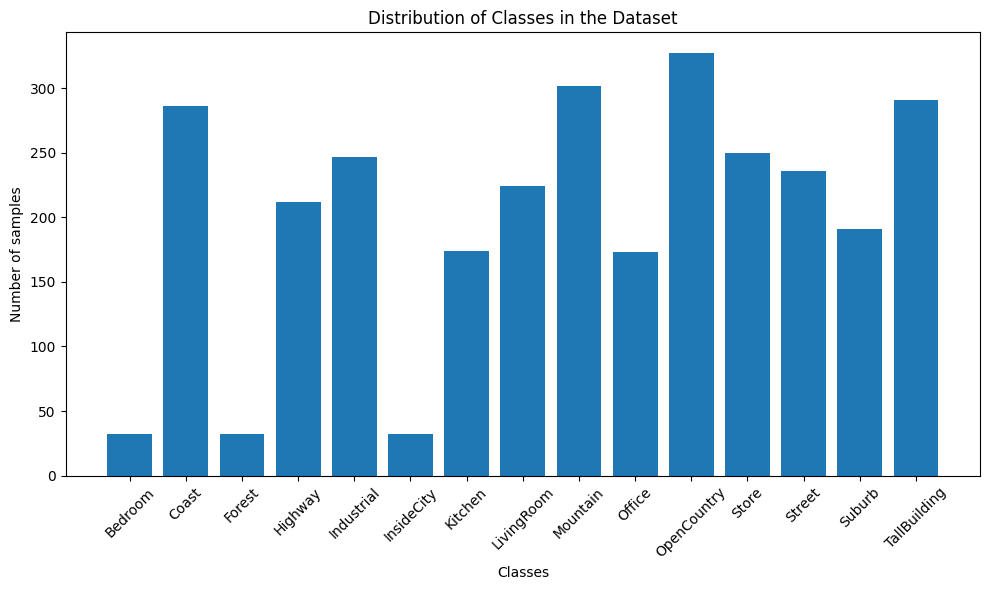


✅ Imbalanced dataset created!


In [ ]:
#Scenario A
student_id = "34590"  # Replace with your student ID
imbalance_type = "uniform_minority" #scenario A
#imbalance_type= "long_tail" # scenario B
severity = "medium"

# Get class distribution and create imbalance profile
train_counts = count_samples_dataset(train_selected, num_classes=num_classes)
max_count = int(max(train_counts))

train_desired_samples_A, minority_classes_A = define_imbalance_profile(
    num_classes=num_classes,
    max_count=max_count,
    student_id=student_id,
    imbalance_type=imbalance_type,
    severity=severity
)
print("==========Scenario A==========")
print(f"Imbalance config: type={imbalance_type}, severity={severity}")
print(f"Desired samples: {train_desired_samples_A}")
print(f"Minority classes: {[class_names[i] for i in minority_classes_A]}\n")

# Apply imbalance (test remains balanced)
seed = int(student_id) if str(student_id).isdigit() else 42
train_imbalanced_A = apply_imbalance(train_selected, train_desired_samples_A, seed=seed)

print("TRAIN (imbalanced):")
inspect_dataset_classes(train_imbalanced_A, class_names=class_names)

print("\nTEST (balanced):")
inspect_dataset_classes(test_selected, class_names=class_names)

# Plot distribution
plot_class_distribution(count_samples_dataset(train_imbalanced_A, num_classes=num_classes), class_names)
print("\n✅ Imbalanced dataset created!")

In [ ]:
#Scenario B
student_id = "34590"  # Replace with your student ID
#imbalance_type = "uniform_minority" #scenario A
imbalance_type= "long_tail" # scenario B
severity = "medium"

# Get class distribution and create imbalance profile
train_counts = count_samples_dataset(train_selected, num_classes=num_classes)
max_count = int(max(train_counts))

train_desired_samples_B, minority_classes_B = define_imbalance_profile(
    num_classes=num_classes,
    max_count=max_count,
    student_id=student_id,
    imbalance_type=imbalance_type,
    severity=severity
)
print("==========Scenario B==========")
print(f"Imbalance config: type={imbalance_type}, severity={severity}")
print(f"Desired samples: {train_desired_samples_B}")
print(f"Minority classes: {[class_names[i] for i in minority_classes_B]}\n")

# Apply imbalance (test remains balanced)
seed = int(student_id) if str(student_id).isdigit() else 42
train_imbalanced_B = apply_imbalance(train_selected, train_desired_samples_B, seed=seed)

print("TRAIN (imbalanced):")
inspect_dataset_classes(train_imbalanced_B, class_names=class_names)

print("\nTEST (balanced):")
inspect_dataset_classes(test_selected, class_names=class_names)



==========Scenario B==========
Imbalance config: type=long_tail, severity=medium
Desired samples: [327, 276, 234, 198, 168, 142, 120, 102, 86, 73, 62, 52, 44, 37, 32]
Minority classes: ['TallBuilding', 'Suburb', 'Street']

TRAIN (imbalanced):
Classes present:
  Class 0 (Bedroom): 165 samples
  Class 1 (Coast): 276 samples
  Class 2 (Forest): 234 samples
  Class 3 (Highway): 198 samples
  Class 4 (Industrial): 168 samples
  Class 5 (InsideCity): 142 samples
  Class 6 (Kitchen): 120 samples
  Class 7 (LivingRoom): 102 samples
  Class 8 (Mountain): 86 samples
  Class 9 (Office): 73 samples
  Class 10 (OpenCountry): 62 samples
  Class 11 (Store): 52 samples
  Class 12 (Street): 44 samples
  Class 13 (Suburb): 37 samples
  Class 14 (TallBuilding): 32 samples

TEST (balanced):
Classes present:
  Class 0 (Bedroom): 51 samples
  Class 1 (Coast): 74 samples
  Class 2 (Forest): 73 samples
  Class 3 (Highway): 48 samples
  Class 4 (Industrial): 64 samples
  Class 5 (InsideCity): 53 samples
  Clas

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [51, 74, 73, 48, 64, 53, 36, 65, 72, 42, 83, 65, 56, 50, 65])

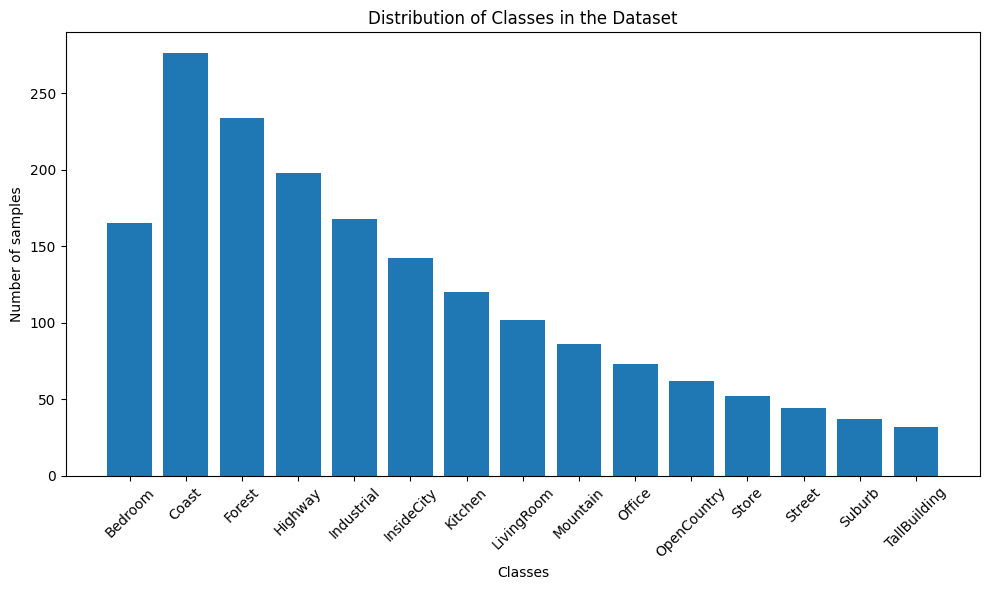


✅ Imbalanced dataset created!


In [ ]:
# Plot distribution
plot_class_distribution(count_samples_dataset(train_imbalanced_B, num_classes=num_classes), class_names)
print("\n✅ Imbalanced dataset created!")

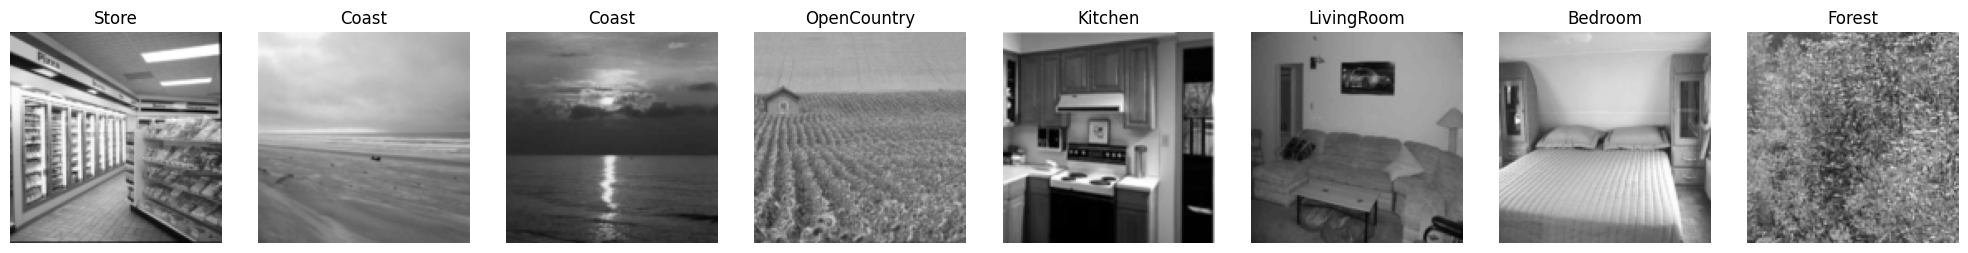

In [ ]:
show_images(train_imbalanced_B, selected_class_names)

In [ ]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # After 4 pooling layers: 128x128 -> 8x8
        self.fc1 = nn.Linear(512 * 8 * 8, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.pool(self.relu(self.conv4(x)))
        x = x.view(-1, 512 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

print("✅ SimpleCNN defined!")

✅ SimpleCNN defined!


In [ ]:
# Scenario A :
#+++++++++++++++


import torch
import torch.optim as optim
from torch.utils.data import DataLoader

#hyperparameters
num_workers=4
num_epochs=10
batch_size=64
lr=0.001
weight_decay=1e-5

# Setup dataloaders
#train_loader = DataLoader(train_selected, batch_size=batch_size, shuffle=True, num_workers=num_workers) #balanced train set
train_loader_A_baseline = DataLoader(train_imbalanced_A, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(test_selected, batch_size=batch_size, shuffle=False, num_workers=num_workers)
print("\n Scenario A_Train batches:", len(train_loader_A_baseline), "| Test batches:", len(test_loader))

# Setup device, model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_A_baseline = SimpleCNN(num_classes).to(device)
criterion_baseline = nn.CrossEntropyLoss()
optimizer_A_baseline = optim.Adam(model_A_baseline.parameters(), lr=lr, weight_decay=weight_decay)
print("✅ Training setup ready!")


 Scenario A_Train batches: 48 | Test batches: 15
✅ Training setup ready!


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Training loop
print(f"Running SCENARIO A - BASELINE training in {device} mode for {num_epochs} epochs")
for epoch in range(num_epochs):
    model_A_baseline.train()
    running_loss = 0.0

    for images, labels in train_loader_A_baseline:
        images, labels = images.to(device), labels.to(device)
        optimizer_A_baseline.zero_grad()
        outputs = model_A_baseline(images)
        loss = criterion_baseline(outputs, labels)
        loss.backward()
        optimizer_A_baseline.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader_A_baseline.dataset)

    # evaluate epoch results
    model_A_baseline.eval()
    train_accuracy, train_labels_A_bl, train_preds_A_bl = calculate_accuracy(train_loader_A_baseline, model_A_baseline)
    test_accuracy, test_labels_A_bl, test_preds_A_bl = calculate_accuracy(test_loader, model_A_baseline)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%')

print("✅ Scenario A - Baseline training completed!")


Running SCENARIO A - BASELINE training in cuda mode for 10 epochs
Epoch [1/10], Loss: 2.5775, Train Accuracy: 20.70%, Test Accuracy: 15.83%
Epoch [2/10], Loss: 2.2975, Train Accuracy: 27.98%, Test Accuracy: 21.74%
Epoch [3/10], Loss: 1.8491, Train Accuracy: 49.09%, Test Accuracy: 38.80%
Epoch [4/10], Loss: 1.5672, Train Accuracy: 56.76%, Test Accuracy: 44.15%
Epoch [5/10], Loss: 1.3873, Train Accuracy: 58.69%, Test Accuracy: 45.82%
Epoch [6/10], Loss: 1.2068, Train Accuracy: 68.36%, Test Accuracy: 51.73%
Epoch [7/10], Loss: 1.0964, Train Accuracy: 70.46%, Test Accuracy: 50.61%
Epoch [8/10], Loss: 0.9158, Train Accuracy: 75.77%, Test Accuracy: 54.29%
Epoch [9/10], Loss: 0.8226, Train Accuracy: 74.88%, Test Accuracy: 51.73%
Epoch [10/10], Loss: 0.7244, Train Accuracy: 86.21%, Test Accuracy: 58.64%
✅ Scenario A - Baseline training completed!


SCENARIO A - TRAIN - Baseline - Accuracy per class:
Overall accuracy (micro, all samples): 86.21%
Mean per-class accuracy (macro):        76.95%

Per-class accuracy:
Bedroom: 6.25% (Samples: 32/3009)
Coast: 94.41% (Samples: 286/3009)
Forest: 71.88% (Samples: 32/3009)
Highway: 89.15% (Samples: 212/3009)
Industrial: 74.09% (Samples: 247/3009)
InsideCity: 15.62% (Samples: 32/3009)
Kitchen: 89.08% (Samples: 174/3009)
LivingRoom: 76.79% (Samples: 224/3009)
Mountain: 86.09% (Samples: 302/3009)
Office: 86.71% (Samples: 173/3009)
OpenCountry: 72.17% (Samples: 327/3009)
Store: 98.00% (Samples: 250/3009)
Street: 95.76% (Samples: 236/3009)
Suburb: 98.95% (Samples: 191/3009)
TallBuilding: 99.31% (Samples: 291/3009)

Std of per-class accuracies:            27.54%

SCENARIO A - TEST - Baseline - Accuracy per class:
Overall accuracy (micro, all samples): 58.64%
Mean per-class accuracy (macro):        57.16%

Per-class accuracy:
Bedroom: 1.96% (Samples: 51/897)
Coast: 83.78% (Samples: 74/897)
Forest: 

Text(0.5, 1.0, 'Scenario A - Baseline - Train Confusion Matrix')

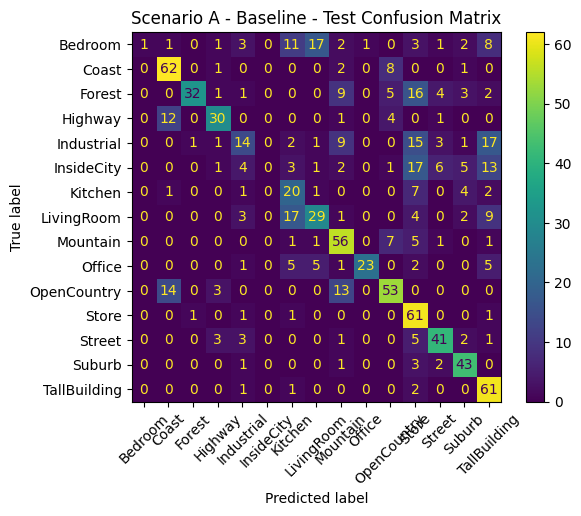

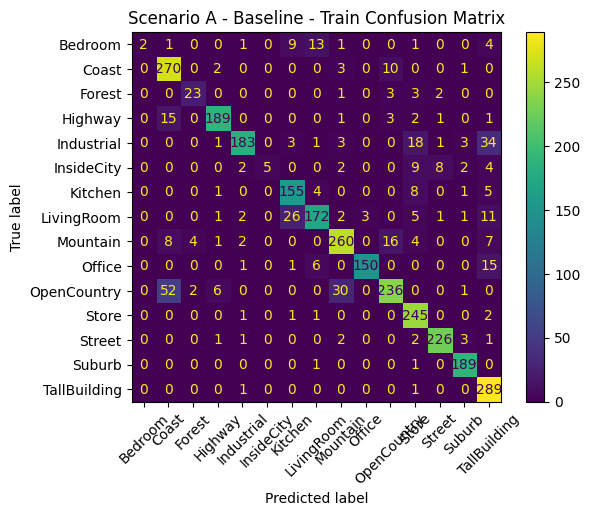

In [ ]:

### SCENARIO A - Baseline Evaluation ###
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#============================================================================
# Per-class accuracy
#============================================================================
print_accuracy_report(train_labels_A_bl, train_preds_A_bl,
                     class_names=class_names,
                     header="SCENARIO A - TRAIN - Baseline - Accuracy per class:",
                     samples_per_class=count_samples_dataset(train_imbalanced_A, num_classes=num_classes))

print_accuracy_report(test_labels_A_bl, test_preds_A_bl,
                     class_names=class_names,
                     header="\nSCENARIO A - TEST - Baseline - Accuracy per class:",
                     samples_per_class=count_samples_dataset(test_selected, num_classes=num_classes))

#============================================================================
# Confusion matrix
#============================================================================
cm_test = confusion_matrix(test_labels_A_bl, test_preds_A_bl)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp.plot(xticks_rotation = 45)
plt.title('Scenario A - Baseline - Test Confusion Matrix')

cm_train = confusion_matrix(train_labels_A_bl, train_preds_A_bl)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=class_names)
disp_train.plot(xticks_rotation = 45)
plt.title('Scenario A - Baseline - Train Confusion Matrix')

Scenario A :weighted Loss strategie

In [ ]:
import torch
import numpy as np

num_classes = len(selected_class_names)

# Calculate class weights
class_counts_A = train_desired_samples_A
class_weights_A = torch.tensor([1.0 / (count+np.finfo(float).eps) for count in class_counts_A], dtype=torch.float).to(device)

# Optional scaling factor (kept for experimentation / teaching)
# Default: uniform scaling (no effect)
factor_A = torch.ones(num_classes,device=device)


criterion_A_weighted = nn.CrossEntropyLoss(weight= factor_A*class_weights_A)
# Create a weighted loss function

print("Scenario A:weighred loss :", selected_class_names)
print("Samples per class:", train_desired_samples_A)
print("Class weights:", class_weights_A)
print("Class weights for loss computation:", factor_A*class_weights_A)
print("✅ Weighted loss based on class frequency defined!")

Scenario A:weighred loss : ['Bedroom', 'Coast', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']
Samples per class: [32, 327, 32, 327, 327, 32, 327, 327, 327, 327, 327, 327, 327, 327, 327]
Class weights: tensor([0.0312, 0.0031, 0.0312, 0.0031, 0.0031, 0.0312, 0.0031, 0.0031, 0.0031,
        0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031], device='cuda:0')
Class weights for loss computation: tensor([0.0312, 0.0031, 0.0312, 0.0031, 0.0031, 0.0312, 0.0031, 0.0031, 0.0031,
        0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031], device='cuda:0')
✅ Weighted loss based on class frequency defined!


In [ ]:
num_workers=4
num_epochs=10
batch_size=64
lr=0.001
weight_decay=1e-5
train_loader_A_weighted = DataLoader(train_imbalanced_A, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(test_selected, batch_size=batch_size, shuffle=False, num_workers=num_workers)
print("\nScenario A - Train batches:", len(train_loader_A_weighted), "| Test batches:", len(test_loader))

# Setup device, model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_A_weighted = SimpleCNN(num_classes).to(device)
optimizer_A_weighted = optim.Adam(model_A_weighted.parameters(), lr=lr, weight_decay=weight_decay)
print("✅ Scenario A - Weighted loss training setup ready!")


Scenario A - Train batches: 48 | Test batches: 15
✅ Scenario A - Weighted loss training setup ready!


In [ ]:
### SCENARIO A - Weighted Loss Training Loop ###
print(f"Running SCENARIO A - WEIGHTED LOSS training in {device} mode for {num_epochs} epochs")
for epoch in range(num_epochs):
    model_A_weighted.train()
    running_loss = 0.0

    for images, labels in train_loader_A_weighted:
        images, labels = images.to(device), labels.to(device)
        optimizer_A_weighted.zero_grad()
        outputs = model_A_weighted(images)
        loss = criterion_A_weighted(outputs, labels)
        loss.backward()
        optimizer_A_weighted.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader_A_weighted.dataset)

    # evaluate epoch results
    model_A_weighted.eval()
    train_accuracy, train_labels_A_wt, train_preds_A_wt = calculate_accuracy(train_loader_A_weighted, model_A_weighted)
    test_accuracy, test_labels_A_wt, test_preds_A_wt = calculate_accuracy(test_loader, model_A_weighted)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%')
print("✅ Scenario A - Weighted loss training completed!")

Running SCENARIO A - WEIGHTED LOSS training in cuda mode for 10 epochs
Epoch [1/10], Loss: 2.6967, Train Accuracy: 9.70%, Test Accuracy: 8.47%
Epoch [2/10], Loss: 2.4654, Train Accuracy: 27.92%, Test Accuracy: 23.08%
Epoch [3/10], Loss: 2.2103, Train Accuracy: 39.38%, Test Accuracy: 32.33%
Epoch [4/10], Loss: 2.0155, Train Accuracy: 39.95%, Test Accuracy: 36.01%
Epoch [5/10], Loss: 1.8139, Train Accuracy: 40.88%, Test Accuracy: 38.46%
Epoch [6/10], Loss: 1.6465, Train Accuracy: 47.99%, Test Accuracy: 39.13%
Epoch [7/10], Loss: 1.5118, Train Accuracy: 54.94%, Test Accuracy: 48.27%
Epoch [8/10], Loss: 1.2263, Train Accuracy: 60.32%, Test Accuracy: 54.18%
Epoch [9/10], Loss: 1.1112, Train Accuracy: 67.36%, Test Accuracy: 55.41%
Epoch [10/10], Loss: 1.0156, Train Accuracy: 70.95%, Test Accuracy: 58.75%
✅ Scenario A - Weighted loss training completed!


SCENARIO A - TRAIN - Weighted Loss - Accuracy per class:
Overall accuracy (micro, all samples): 70.95%
Mean per-class accuracy (macro):        76.64%

Per-class accuracy:
Bedroom: 100.00% (Samples: 32/3009)
Coast: 93.71% (Samples: 286/3009)
Forest: 100.00% (Samples: 32/3009)
Highway: 71.70% (Samples: 212/3009)
Industrial: 43.32% (Samples: 247/3009)
InsideCity: 100.00% (Samples: 32/3009)
Kitchen: 70.69% (Samples: 174/3009)
LivingRoom: 41.07% (Samples: 224/3009)
Mountain: 59.27% (Samples: 302/3009)
Office: 87.86% (Samples: 173/3009)
OpenCountry: 62.69% (Samples: 327/3009)
Store: 80.40% (Samples: 250/3009)
Street: 82.63% (Samples: 236/3009)
Suburb: 89.53% (Samples: 191/3009)
TallBuilding: 66.67% (Samples: 291/3009)

Std of per-class accuracies:            18.80%

SCENARIO A - TEST - Weighted Loss - Accuracy per class:
Overall accuracy (micro, all samples): 58.75%
Mean per-class accuracy (macro):        58.48%

Per-class accuracy:
Bedroom: 31.37% (Samples: 51/897)
Coast: 83.78% (Samples: 7

Text(0.5, 1.0, 'Scenario A - Weighted Loss - Train Confusion Matrix')

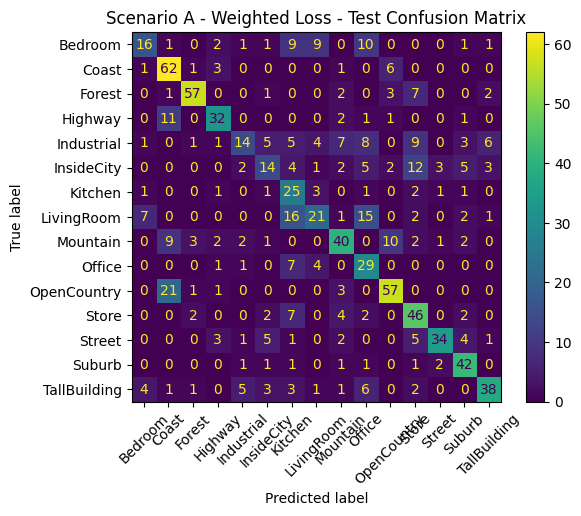

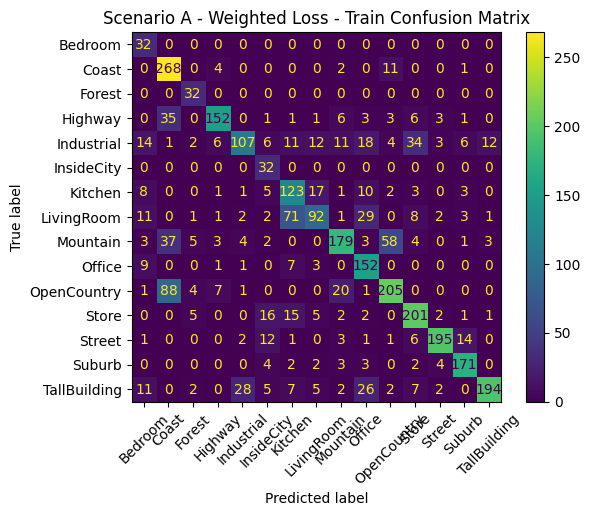

In [ ]:
### SCENARIO A - Weighted Loss Evaluation ###
print_accuracy_report(train_labels_A_wt, train_preds_A_wt,
                     class_names=class_names,
                     header="SCENARIO A - TRAIN - Weighted Loss - Accuracy per class:",
                     samples_per_class=count_samples_dataset(train_imbalanced_A, num_classes=num_classes))

print_accuracy_report(test_labels_A_wt, test_preds_A_wt,
                     class_names=class_names,
                     header="\nSCENARIO A - TEST - Weighted Loss - Accuracy per class:",
                     samples_per_class=count_samples_dataset(test_selected, num_classes=num_classes))

#============================================================================
# Confusion matrix
#============================================================================
cm_test = confusion_matrix(test_labels_A_wt, test_preds_A_wt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp.plot(xticks_rotation = 45)
plt.title('Scenario A - Weighted Loss - Test Confusion Matrix')

cm_train = confusion_matrix(train_labels_A_wt, train_preds_A_wt)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=class_names)
disp_train.plot(xticks_rotation = 45)
plt.title('Scenario A - Weighted Loss - Train Confusion Matrix')

# Scenario B Baseline

In [ ]:
### SCENARIO B - Baseline Training Setup ###
# Setup dataloaders for Scenario B
train_loader_B_baseline = DataLoader(train_imbalanced_B, batch_size=batch_size, shuffle=True, num_workers=num_workers)
print("\nScenario B - Train batches:", len(train_loader_B_baseline), "| Test batches:", len(test_loader))

# Setup model and optimizer
model_B_baseline = SimpleCNN(num_classes).to(device)
optimizer_B_baseline = optim.Adam(model_B_baseline.parameters(), lr=lr, weight_decay=weight_decay)
print("✅ Scenario B - Baseline training setup ready!")


Scenario B - Train batches: 28 | Test batches: 15
✅ Scenario B - Baseline training setup ready!


In [ ]:
### SCENARIO B - Baseline Training Loop ###
print(f"Running SCENARIO B - BASELINE training in {device} mode for {num_epochs} epochs")
for epoch in range(num_epochs):
    model_B_baseline.train()
    running_loss = 0.0

    for images, labels in train_loader_B_baseline:
        images, labels = images.to(device), labels.to(device)
        optimizer_B_baseline.zero_grad()
        outputs = model_B_baseline(images)
        loss = criterion_baseline(outputs, labels)
        loss.backward()
        optimizer_B_baseline.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader_B_baseline.dataset)

    # evaluate epoch results
    model_B_baseline.eval()
    train_accuracy, train_labels_B_bl, train_preds_B_bl = calculate_accuracy(train_loader_B_baseline, model_B_baseline)
    test_accuracy, test_labels_B_bl, test_preds_B_bl = calculate_accuracy(test_loader, model_B_baseline)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%')

print("✅ Scenario B - Baseline training completed!")

Running SCENARIO B - BASELINE training in cuda mode for 10 epochs
Epoch [1/10], Loss: 2.5534, Train Accuracy: 18.70%, Test Accuracy: 10.03%
Epoch [2/10], Loss: 2.1911, Train Accuracy: 34.51%, Test Accuracy: 20.74%
Epoch [3/10], Loss: 1.8666, Train Accuracy: 43.22%, Test Accuracy: 25.75%
Epoch [4/10], Loss: 1.6506, Train Accuracy: 53.32%, Test Accuracy: 35.90%
Epoch [5/10], Loss: 1.5023, Train Accuracy: 56.34%, Test Accuracy: 38.02%
Epoch [6/10], Loss: 1.3769, Train Accuracy: 59.69%, Test Accuracy: 39.02%
Epoch [7/10], Loss: 1.2286, Train Accuracy: 63.54%, Test Accuracy: 40.91%
Epoch [8/10], Loss: 1.1147, Train Accuracy: 65.66%, Test Accuracy: 42.81%
Epoch [9/10], Loss: 1.0040, Train Accuracy: 71.36%, Test Accuracy: 44.26%
Epoch [10/10], Loss: 0.8986, Train Accuracy: 74.48%, Test Accuracy: 45.93%
✅ Scenario B - Baseline training completed!


SCENARIO B - TRAIN - Baseline - Accuracy per class:
Overall accuracy (micro, all samples): 74.48%
Mean per-class accuracy (macro):        64.55%

Per-class accuracy:
Bedroom: 69.70% (Samples: 165/1791)
Coast: 99.28% (Samples: 276/1791)
Forest: 91.03% (Samples: 234/1791)
Highway: 67.17% (Samples: 198/1791)
Industrial: 69.05% (Samples: 168/1791)
InsideCity: 85.92% (Samples: 142/1791)
Kitchen: 83.33% (Samples: 120/1791)
LivingRoom: 51.96% (Samples: 102/1791)
Mountain: 52.33% (Samples: 86/1791)
Office: 93.15% (Samples: 73/1791)
OpenCountry: 25.81% (Samples: 62/1791)
Store: 51.92% (Samples: 52/1791)
Street: 72.73% (Samples: 44/1791)
Suburb: 48.65% (Samples: 37/1791)
TallBuilding: 6.25% (Samples: 32/1791)

Std of per-class accuracies:            24.87%

SCENARIO B - TEST - Baseline - Accuracy per class:
Overall accuracy (micro, all samples): 45.93%
Mean per-class accuracy (macro):        47.26%

Per-class accuracy:
Bedroom: 41.18% (Samples: 51/897)
Coast: 94.59% (Samples: 74/897)
Forest: 86.

Text(0.5, 1.0, 'Scenario B - Baseline - Train Confusion Matrix')

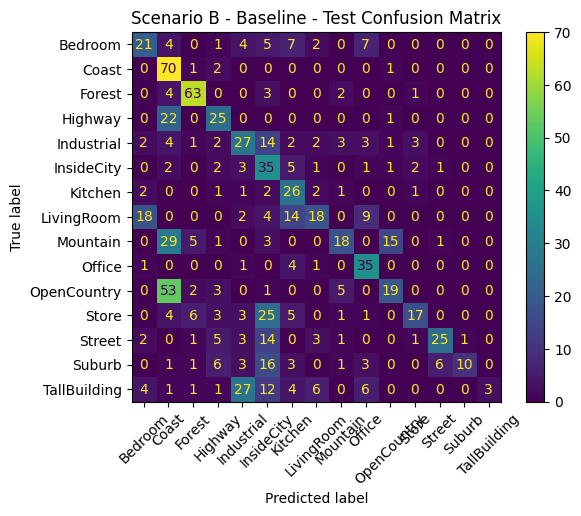

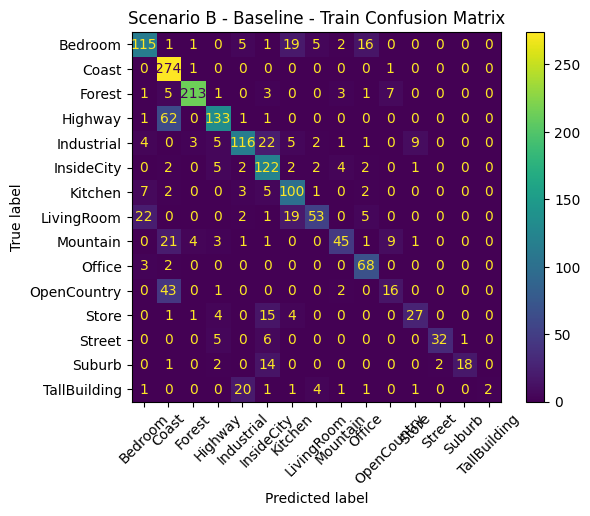

In [ ]:
### SCENARIO B - Baseline Evaluation ###
print_accuracy_report(train_labels_B_bl, train_preds_B_bl,
                     class_names=class_names,
                     header="SCENARIO B - TRAIN - Baseline - Accuracy per class:",
                     samples_per_class=count_samples_dataset(train_imbalanced_B, num_classes=num_classes))

print_accuracy_report(test_labels_B_bl, test_preds_B_bl,
                     class_names=class_names,
                     header="\nSCENARIO B - TEST - Baseline - Accuracy per class:",
                     samples_per_class=count_samples_dataset(test_selected, num_classes=num_classes))

#============================================================================
# Confusion matrix
#============================================================================
cm_test = confusion_matrix(test_labels_B_bl, test_preds_B_bl)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp.plot(xticks_rotation = 45)
plt.title('Scenario B - Baseline - Test Confusion Matrix')

cm_train = confusion_matrix(train_labels_B_bl, train_preds_B_bl)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=class_names)
disp_train.plot(xticks_rotation = 45)
plt.title('Scenario B - Baseline - Train Confusion Matrix')

In [ ]:
### SCENARIO B - Weighted Loss Setup ###
# Calculate class weights based on Scenario B imbalance
class_counts_B = train_desired_samples_B
class_weights_B = torch.tensor([1.0 / (count+np.finfo(float).eps) for count in class_counts_B], dtype=torch.float).to(device)

# Optional scaling factor (can be adjusted per class if needed)
factor_B = torch.tensor([1.0] * num_classes, device=device)

# Create weighted loss criterion
criterion_B_weighted = nn.CrossEntropyLoss(weight=factor_B * class_weights_B)

print("SCENARIO B - Weighted Loss Strategy")
print("Selected classes:", class_names)
print("Samples per class:", train_desired_samples_B)
print("Class weights:", class_weights_B)
print("Class weights for loss computation:", factor_B * class_weights_B)
print("✅ Scenario B - Weighted loss defined!")

SCENARIO B - Weighted Loss Strategy
Selected classes: ['Bedroom', 'Coast', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']
Samples per class: [327, 276, 234, 198, 168, 142, 120, 102, 86, 73, 62, 52, 44, 37, 32]
Class weights: tensor([0.0031, 0.0036, 0.0043, 0.0051, 0.0060, 0.0070, 0.0083, 0.0098, 0.0116,
        0.0137, 0.0161, 0.0192, 0.0227, 0.0270, 0.0312], device='cuda:0')
Class weights for loss computation: tensor([0.0031, 0.0036, 0.0043, 0.0051, 0.0060, 0.0070, 0.0083, 0.0098, 0.0116,
        0.0137, 0.0161, 0.0192, 0.0227, 0.0270, 0.0312], device='cuda:0')
✅ Scenario B - Weighted loss defined!


In [ ]:
### SCENARIO B - Weighted Loss Training Setup ###
train_loader_B_weighted = DataLoader(train_imbalanced_B, batch_size=batch_size, shuffle=True, num_workers=num_workers)
print("\nScenario B - Train batches:", len(train_loader_B_weighted), "| Test batches:", len(test_loader))

# Setup model and optimizer
model_B_weighted = SimpleCNN(num_classes).to(device)
optimizer_B_weighted = optim.Adam(model_B_weighted.parameters(), lr=lr, weight_decay=weight_decay)
print("✅ Scenario B - Weighted loss training setup ready!")


Scenario B - Train batches: 28 | Test batches: 15
✅ Scenario B - Weighted loss training setup ready!


In [ ]:
### SCENARIO B - Weighted Loss Training Loop ###
print(f"Running SCENARIO B - WEIGHTED LOSS training in {device} mode for {num_epochs} epochs")
for epoch in range(num_epochs):
    model_B_weighted.train()
    running_loss = 0.0

    for images, labels in train_loader_B_weighted:
        images, labels = images.to(device), labels.to(device)
        optimizer_B_weighted.zero_grad()
        outputs = model_B_weighted(images)
        loss = criterion_B_weighted(outputs, labels)
        loss.backward()
        optimizer_B_weighted.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader_B_weighted.dataset)

    # evaluate epoch results
    model_B_weighted.eval()
    train_accuracy, train_labels_B_wt, train_preds_B_wt = calculate_accuracy(train_loader_B_weighted, model_B_weighted)
    test_accuracy, test_labels_B_wt, test_preds_B_wt = calculate_accuracy(test_loader, model_B_weighted)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%')
print("✅ Scenario B - Weighted loss training completed!")

Running SCENARIO B - WEIGHTED LOSS training in cuda mode for 10 epochs
Epoch [1/10], Loss: 2.7098, Train Accuracy: 8.82%, Test Accuracy: 10.14%
Epoch [2/10], Loss: 2.6234, Train Accuracy: 26.63%, Test Accuracy: 19.51%
Epoch [3/10], Loss: 2.3159, Train Accuracy: 32.05%, Test Accuracy: 28.43%
Epoch [4/10], Loss: 2.1085, Train Accuracy: 37.74%, Test Accuracy: 31.66%
Epoch [5/10], Loss: 1.9836, Train Accuracy: 44.56%, Test Accuracy: 32.78%
Epoch [6/10], Loss: 1.8243, Train Accuracy: 44.44%, Test Accuracy: 38.68%
Epoch [7/10], Loss: 1.6737, Train Accuracy: 46.68%, Test Accuracy: 38.24%
Epoch [8/10], Loss: 1.5310, Train Accuracy: 58.91%, Test Accuracy: 41.69%
Epoch [9/10], Loss: 1.3520, Train Accuracy: 60.47%, Test Accuracy: 45.60%
Epoch [10/10], Loss: 1.1967, Train Accuracy: 66.11%, Test Accuracy: 48.27%
✅ Scenario B - Weighted loss training completed!


SCENARIO B - TRAIN - Weighted Loss - Accuracy per class:
Overall accuracy (micro, all samples): 66.11%
Mean per-class accuracy (macro):        71.60%

Per-class accuracy:
Bedroom: 34.55% (Samples: 165/1791)
Coast: 73.91% (Samples: 276/1791)
Forest: 72.65% (Samples: 234/1791)
Highway: 77.27% (Samples: 198/1791)
Industrial: 40.48% (Samples: 168/1791)
InsideCity: 51.41% (Samples: 142/1791)
Kitchen: 67.50% (Samples: 120/1791)
LivingRoom: 79.41% (Samples: 102/1791)
Mountain: 41.86% (Samples: 86/1791)
Office: 82.19% (Samples: 73/1791)
OpenCountry: 70.97% (Samples: 62/1791)
Store: 90.38% (Samples: 52/1791)
Street: 97.73% (Samples: 44/1791)
Suburb: 100.00% (Samples: 37/1791)
TallBuilding: 93.75% (Samples: 32/1791)

Std of per-class accuracies:            20.32%

SCENARIO B - TEST - Weighted Loss - Accuracy per class:
Overall accuracy (micro, all samples): 48.27%
Mean per-class accuracy (macro):        47.80%

Per-class accuracy:
Bedroom: 25.49% (Samples: 51/897)
Coast: 68.92% (Samples: 74/897)

Text(0.5, 1.0, 'Scenario B - Weighted Loss - Train Confusion Matrix')

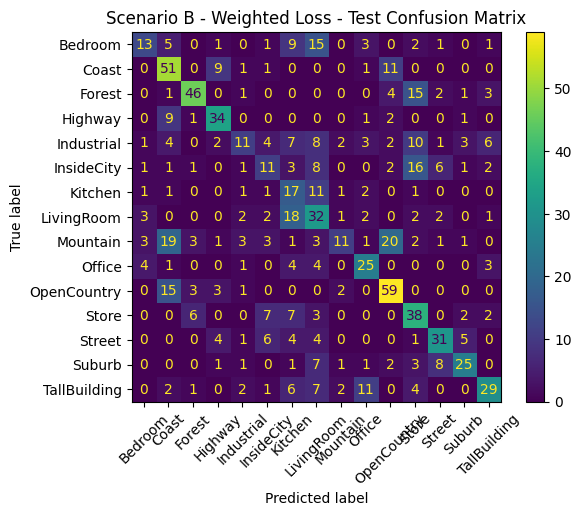

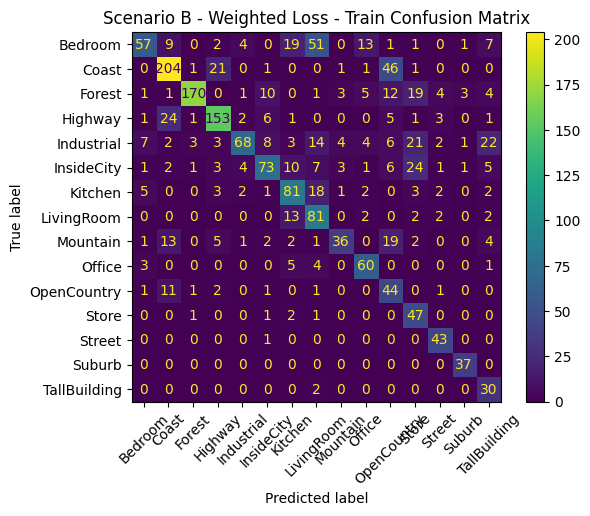

In [ ]:
### SCENARIO B - Weighted Loss Evaluation ###
print_accuracy_report(train_labels_B_wt, train_preds_B_wt,
                     class_names=class_names,
                     header="SCENARIO B - TRAIN - Weighted Loss - Accuracy per class:",
                     samples_per_class=count_samples_dataset(train_imbalanced_B, num_classes=num_classes))

print_accuracy_report(test_labels_B_wt, test_preds_B_wt,
                     class_names=class_names,
                     header="\nSCENARIO B - TEST - Weighted Loss - Accuracy per class:",
                     samples_per_class=count_samples_dataset(test_selected, num_classes=num_classes))

#============================================================================
# Confusion matrix
#============================================================================
cm_test = confusion_matrix(test_labels_B_wt, test_preds_B_wt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp.plot(xticks_rotation = 45)
plt.title('Scenario B - Weighted Loss - Test Confusion Matrix')

cm_train = confusion_matrix(train_labels_B_wt, train_preds_B_wt)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=class_names)
disp_train.plot(xticks_rotation = 45)
plt.title('Scenario B - Weighted Loss - Train Confusion Matrix')